In [2]:
#!pip install ppscore

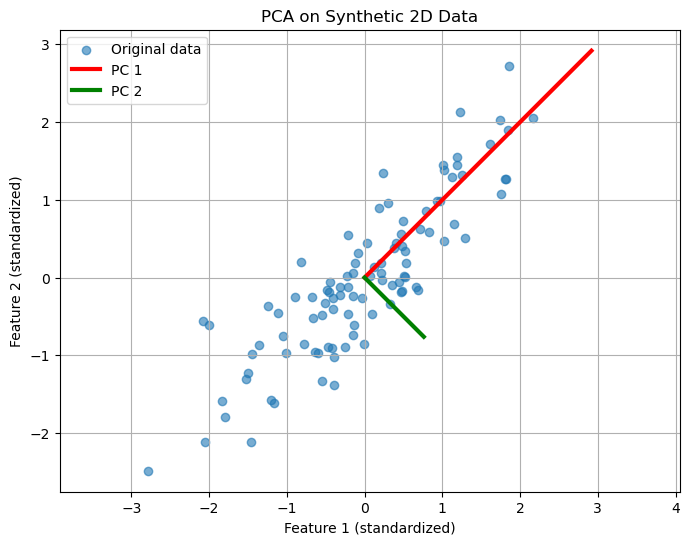

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic 2D data (correlated features)
np.random.seed(42)
x = np.random.normal(0, 1, 100)
y = 2 * x + np.random.normal(0, 1, 100)
X = np.column_stack((x, y))

# Standardize data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Get principal components
components = pca.components_
mean = pca.mean_

# Plot original data and PCA axes
plt.figure(figsize=(8, 6))
plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.6, label="Original data")
for length, vector in zip(pca.explained_variance_, components):
    v = vector * 3 * np.sqrt(length)
    plt.plot([mean[0], mean[0] + v[0]], [mean[1], mean[1] + v[1]],
             color='red' if np.allclose(vector, components[0]) else 'green',
             linewidth=3, label=f"PC {'1' if np.allclose(vector, components[0]) else '2'}")

plt.axis('equal')
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.title("PCA on Synthetic 2D Data")
plt.legend()
plt.grid(True)
plt.show()
